In [12]:
import pandas as pd
import numpy as np

# Make numpy values easier to read.
np.set_printoptions(precision=3, suppress=True)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [6]:
data = pd.read_csv('XFEL_KW0_Results_2.csv', names=None)

# find constant columns, else normalization wouldn't work
data = data.loc[:, (data != data.iloc[0]).any()] 

# label input 0-6, output 0-4 just for clarity
num_inputs = 7
num_outputs = 5
data.columns = np.concatenate(
    (["Input %s" % i for i in range(num_inputs)], ["Output %s" % i for i in range(num_outputs)])
)

In [14]:
# normalization to 0-mean and std of 1:)
normalized_data = (data-data.mean())/data.std()

# TODO: k-fold cross-validation
train, test = train_test_split(normalized_data, test_size=0.2, random_state=42, shuffle=True)
#train, validation = train_test_split(train, test_size=0.2, random_state=42, shuffle=True)

# numpy indexing [columns_start : columns_end, rows_start : rows_end]
x_train, y_train = train.iloc[:,:num_inputs], train.iloc[:,num_inputs:]
#x_val, y_val = validation.iloc[:,:num_inputs], validation.iloc[:,num_inputs:]
x_test, y_test = test.iloc[:,:num_inputs], test.iloc[:,num_inputs:]
x_train

,Input 0,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6
1038995,-0.142617,-0.282070,-1.200246,-1.127906,-0.208917,-0.348914,-1.405966
722968,0.904406,1.063992,1.219414,-1.297223,-0.208917,0.960046,0.497041
910777,-0.142617,1.063992,0.302264,-1.025267,-1.256424,1.832686,-1.044136
244439,0.206391,-0.282070,-0.248604,1.112297,-1.605593,0.960046,-0.140033
207420,0.904406,1.512679,-1.393442,-1.595583,0.838591,0.523726,0.353318
...,...,...,...,...,...,...,...
110268,-0.491624,-0.730757,1.497710,-0.948076,-1.605593,0.523726,-1.122408
259178,0.206391,-0.282070,1.310009,-0.219495,0.838591,-0.348914,0.052793
131932,0.555398,-1.179444,0.967981,0.843331,-0.558086,-0.785234,0.290463
671155,1.253413,1.512679,0.061276,-0.148904,1.536930,0.960046,1.071831


In [19]:
# Model creation
def create_model(hidden_depth = 1, lr=0.01, actv_fct='relu'):
    model = keras.Sequential([
        keras.Input(shape=(num_inputs)),
        *[
            keras.layers.Dense(16, activation=actv_fct) 
            for _ in range(hidden_depth)
        ],
        keras.layers.Dense(num_outputs)
    ])
    
    print(model.summary())
    print('learning rate: ', lr, ' activation function: ', actv_fct)

    optimizer = keras.optimizers.SGD(learning_rate=lr)
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    return model

In [ ]:
print(tf.config.list_physical_devices('GPU'))

In [20]:
# Gridsearch with k-fold cross validation

from sklearn.model_selection import GridSearchCV, KFold
from keras.wrappers.scikit_learn import KerasRegressor

param_grid = {
    'hidden_depth': [i for i in range(2,4)],
    'lr': [0.005*i for i in range(2,4)],
    'actv_fct': ['relu', 'sigmoid']
}
loss = keras.losses.MeanSquaredError()

model = KerasRegressor(build_fn=create_model)

# Specify the number of folds for cross-validation
n_splits = 3

# Create a cross-validation object (KFold in this case)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform grid search with cross-validation
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=kf, scoring='neg_mean_squared_error')
grid_result = grid.fit(x_train, y_train)

# Print the best hyperparameters and results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

C:\Users\Maris\AppData\Local\Temp\ipykernel_14584\2776945825.py:13: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasRegressor(build_fn=create_model)


Model: "sequential_232"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1005 (Dense)          (None, 16)                128       
                                                                 
 dense_1006 (Dense)          (None, 16)                272       
                                                                 
 dense_1007 (Dense)          (None, 5)                 85        
                                                                 
Total params: 485
Trainable params: 485
Non-trainable params: 0
_________________________________________________________________
None
learning rate:  0.01  activation function:  relu
9424/9424 [==============================] - 25s 3ms/step
Model: "sequential_233"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1008 (Dense)          (None, 16)           

In [85]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=7),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='relu'),
    layers.Dense(4),
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(0.1),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['accuracy']
)

history = model.fit(
    xtrain, ytrain,
    batch_size=200,
    epochs=8,
    validation_data = (xtest, ytest),
)

Epoch 1/8
4524/4524 [==============================] - 23s 5ms/step - loss: 0.0410 - accuracy: 0.6158 - val_loss: 0.0221 - val_accuracy: 0.7929
Epoch 2/8
4524/4524 [==============================] - 17s 4ms/step - loss: 0.0211 - accuracy: 0.8316 - val_loss: 0.0209 - val_accuracy: 0.8394
Epoch 3/8
4524/4524 [==============================] - 14s 3ms/step - loss: 0.0203 - accuracy: 0.8356 - val_loss: 0.0188 - val_accuracy: 0.8320
Epoch 4/8
4524/4524 [==============================] - 16s 4ms/step - loss: 0.0097 - accuracy: 0.8717 - val_loss: 0.0013 - val_accuracy: 0.9344
Epoch 5/8
4524/4524 [==============================] - 18s 4ms/step - loss: 7.7855e-04 - accuracy: 0.9402 - val_loss: 3.0183e-04 - val_accuracy: 0.9635
Epoch 6/8
4524/4524 [==============================] - 12s 3ms/step - loss: 2.9791e-04 - accuracy: 0.9564 - val_loss: 2.5787e-04 - val_accuracy: 0.9640
Epoch 7/8
4524/4524 [==============================] - 13s 3ms/step - loss: 2.5618e-04 - accuracy: 0.9592 - val_loss: 2.

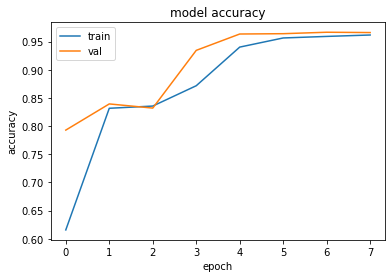

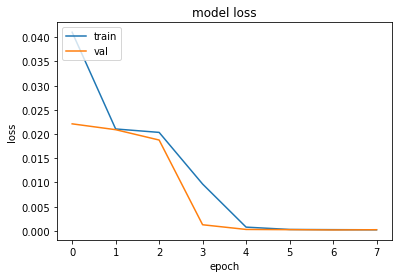

In [86]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [84]:
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(xtest, ytest, batch_size=128)
print("test loss, test acc:", results)

# Generate predictions (probabilities -- the output of the last layer)
# on new data using `predict`
print("Generate predictions for 3 samples")
predictions = model.predict(xtest[:3])
print("example predictions:\n", predictions)

Evaluate on test data
1767/1767 [==============================] - 4s 2ms/step - loss: 2.0094e-04 - accuracy: 0.9647
test loss, test acc: [0.00020094368665013462, 0.9647071957588196]
Generate predictions for 3 samples
1/1 [==============================] - 0s 129ms/step
example predictions:
 [[0.469 0.407 0.176 0.463]
 [0.603 0.601 0.203 0.779]
 [0.66  0.415 0.162 0.564]]
